In [51]:
from typing import TypedDict
from typing_extensions import Annotated
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
# from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [52]:
from dotenv import load_dotenv

load_dotenv()

True

In [53]:
memory = MemorySaver()

In [54]:
class State(TypedDict):
    # Messages have the type "List". The add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [55]:
@tool
def get_stock_price(symbol:str) -> float:
    ''' 
    Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT" : 200.3,
        "AAPL" : 100.4,
        "AMZN" : 150.0,
        "RIL" : 87.6
    }.get(symbol,0.0)

tools = [get_stock_price]

In [64]:
# llm = init_chat_model("google_genai:gemini-2.0-flash")
# llm_with_tools = llm.bind_tools(tools)

llm_with_tools = ChatOllama(model="gemma4:e2b").bind_tools(tools)

In [67]:
def chatbot(state:State):
    return { "messages": [ llm_with_tools.invoke(state["messages"]) ] }


builder = StateGraph(State)

builder.add_node("tools", ToolNode(tools))
builder.add_node("add_chatbot", chatbot)

builder.add_edge(START, "add_chatbot")
builder.add_conditional_edges("add_chatbot", tools_condition)
builder.add_edge("tools", "add_chatbot")

graph = builder.compile(checkpointer=memory)


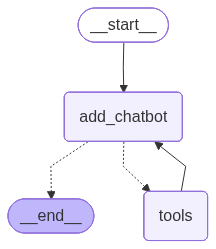

In [68]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [69]:
from langchain_core.runnables import RunnableConfig

config1 : RunnableConfig = { 'configurable' : { 'thread_id': '1' } }
msg = "i want to buy 2 AAPL stocks and 3 MSFT stocks? what will be total cost?"
state = graph.invoke({ "messages" : [{ "role": "user", "content": msg }] }, config=config1)
print(state["messages"][-1].content)

To calculate the cost for buying 2 AAPL and 3 MSFT stocks, I will use the most recently retrieved prices:

*   **AAPL (Apple):** \$100.40 per share
*   **MSFT (Microsoft):** \$200.30 per share

Here is the calculation:

1.  **Cost for AAPL:** 2 shares $\times$ \$100.40/share = **\$200.80**
2.  **Cost for MSFT:** 3 shares $\times$ \$200.30/share = **\$600.90**

**Estimated Total Cost (before fees):** \$200.80 + \$600.90 = **\$801.70**

This is the estimated cost based on the prices I have access to. Remember that the final cost may vary due to brokerage fees and taxes.


In [70]:
msg = "Now add 10 stocks of RIL in previous total cost and provide total cost."
state = graph.invoke({ "messages" : [{ "role": "user", "content": msg }] }, config=config1)
print(state["messages"][-1].content)

To calculate the new total cost, I will add the estimated cost of 10 shares of RIL to the previous total cost of \$801.70.

First, I need the current price for RIL:
*   **RIL (Reliance Industries):** \$87.60 per share

Now, let's calculate the cost for the RIL purchase:
*   **Cost for RIL:** 10 shares $\times$ \$87.60/share = **\$876.00**

**New Total Cost:**
*   Previous Total Cost: \$801.70
*   Cost for RIL: \$876.00
*   **New Total Cost:** \$801.70 + \$876.00 = **\$1,677.70**

**The estimated total cost for 2 AAPL, 3 MSFT, and 10 RIL stocks is \$1,677.70 (before fees).**


In [72]:
msg = "provide me cost of MSFT and now add 5 stocks of MSFT in previous total cost"
state = graph.invoke({ "messages" : [{ "role": "user", "content": msg }] }, config=config1)
print(state["messages"][-1].content)

Based on our previous conversation, here is the breakdown again:

### 1. Current Cost of MSFT:

The price I have on record for MSFT is **\$200.30** per share.

### 2. Adding 5 More MSFT Stocks to the Previous Total Cost:

The previous total cost before this step was **\$1,677.70**.

We calculate the cost of 5 additional MSFT shares:
*   Cost for 5 MSFT: $5 \times \$200.30 = \$1,001.50$

**New Total Cost:**
*   Previous Total Cost: \$1,677.70
*   Cost of 5 MSFTs: \$1,001.50
*   **New Total Cost:** \$1,677.70 + \$1,001.50 = **\$2,679.20**

The new estimated total cost is **\$2,679.20** (before fees).
